In [1]:
import pandas as pd

In [49]:
df=pd.read_csv('data/housing.csv')

In [50]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [51]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [52]:
yes_no_cols=['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[yes_no_cols]=df[yes_no_cols].apply(lambda x: x.map({'yes': 1, 'no': 0}))

In [53]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [54]:
df=pd.get_dummies(df, columns=['furnishingstatus'], dtype=int)

In [55]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


In [56]:
from sklearn.preprocessing import StandardScaler
num_cols=['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
scaler=StandardScaler()
df[num_cols]=scaler.fit_transform(df[num_cols])


In [57]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,1.046726,1.403419,1.421812,1.378217,1,0,0,0,1,1.517692,1,1,0,0
1,12250000,1.757010,1.403419,5.405809,2.532024,1,0,0,0,1,2.679409,0,1,0,0
2,12250000,2.218232,0.047278,1.421812,0.224410,1,0,1,0,0,1.517692,1,0,1,0
3,12215000,1.083624,1.403419,1.421812,0.224410,1,0,1,0,1,2.679409,1,1,0,0
4,11410000,1.046726,1.403419,-0.570187,0.224410,1,1,1,0,1,1.517692,0,1,0,0


In [58]:
#task2
from sklearn.model_selection import train_test_split

In [81]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,1.046726,1.403419,1.421812,1.378217,1,0,0,0,1,1.517692,1,1,0,0
1,12250000,1.757010,1.403419,5.405809,2.532024,1,0,0,0,1,2.679409,0,1,0,0
2,12250000,2.218232,0.047278,1.421812,0.224410,1,0,1,0,0,1.517692,1,0,1,0
3,12215000,1.083624,1.403419,1.421812,0.224410,1,0,1,0,1,2.679409,1,1,0,0
4,11410000,1.046726,1.403419,-0.570187,0.224410,1,1,1,0,1,1.517692,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,-0.991879,-1.308863,-0.570187,-0.929397,1,0,1,0,0,1.517692,0,0,0,1
541,1767150,-1.268613,0.047278,-0.570187,-0.929397,0,0,0,0,0,-0.805741,0,0,1,0
542,1750000,-0.705921,-1.308863,-0.570187,-0.929397,1,0,0,0,0,-0.805741,0,0,0,1
543,1750000,-1.033389,0.047278,-0.570187,-0.929397,0,0,0,0,0,-0.805741,0,1,0,0


In [59]:
x=df.drop('price', axis=1)
y=df['price']

In [60]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

In [61]:
from sklearn.linear_model import LinearRegression

In [63]:
trainer=LinearRegression()
trainer.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [64]:
trainer.coef_

array([ 511615.56377666,   56615.57245779,  549420.50124098,
        353158.42985604,  367919.94767957,  231610.03717565,
        390251.17618109,  684649.88533879,  791426.73584319,
        193542.78167455,  629890.56531336,  180175.62660444,
         53293.80901934, -233469.43562378])

In [65]:
trainer.intercept_

np.float64(3822246.533801671)

In [71]:
#task3
y_pred=trainer.predict(x_test)



In [79]:
y_pred

array([5164653.90033967, 7224722.29802166, 3109863.24240338,
       4612075.3272256 , 3294646.25725956, 3532275.09556558,
       5611774.56836475, 6368145.98732718, 2722856.95689986,
       2629405.61585783, 9617039.50315578, 2798087.30447888,
       3171096.76847064, 3394639.09125529, 3681088.65424276,
       5263187.74621486, 3035963.47612386, 4786122.8004005 ,
       4349551.9200572 , 3572362.09930451, 5774875.21395649,
       5886993.57919883, 2730836.19518459, 4727316.47323635,
       5244847.52716799, 7555324.21605601, 3220790.84680269,
       5191898.79934207, 8143726.91009782, 3398814.09825036,
       6490693.05027926, 3315105.90747811, 6708457.36761326,
       4201738.21071676, 3557571.06735186, 5836974.50478627,
       4808660.67448475, 4362878.73613262, 3191242.95701509,
       4596554.93225239, 4566042.86048409, 3517779.52374149,
       7205844.79365835, 3983597.27861103, 3749338.70271055,
       4274731.09125895, 6757442.10783741, 4037320.43665851,
       3769334.90397125,

In [80]:
y_test

316    4060000
77     6650000
360    3710000
90     6440000
493    2800000
        ...   
15     9100000
357    3773000
39     7910000
54     7350000
155    5530000
Name: price, Length: 109, dtype: int64

In [72]:
len(y_pred)

109

In [69]:
len(df)

545

In [73]:
import numpy as np
mae=np.mean(abs(y_test-y_pred))
mae

np.float64(970043.4039201643)

In [74]:
mse=np.mean((y_test-y_pred)**2)
mse

np.float64(1754318687330.6685)

In [75]:
x_test

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,0.345668,1.403419,1.421812,0.224410,0,0,1,0,0,0.355976,0,0,0,1
77,0.622401,0.047278,1.421812,1.378217,1,0,0,0,1,-0.805741,1,1,0,0
360,-0.512207,-1.308863,-0.570187,-0.929397,1,0,0,0,0,-0.805741,0,0,1,0
90,-0.069433,0.047278,-0.570187,0.224410,1,0,0,0,1,-0.805741,0,0,1,0
493,-0.549105,0.047278,-0.570187,-0.929397,1,0,0,0,0,-0.805741,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,0.391790,1.403419,-0.570187,0.224410,1,0,1,0,0,1.517692,0,0,1,0
357,0.820727,1.403419,-0.570187,0.224410,0,0,0,0,0,0.355976,0,1,0,0
39,0.391790,1.403419,1.421812,2.532024,1,0,0,0,1,0.355976,0,0,1,0
54,0.391790,0.047278,1.421812,0.224410,1,1,0,0,1,0.355976,0,0,1,0


In [78]:
R_squared=trainer.score(x_test, y_test)
R_squared

0.6529242642153175

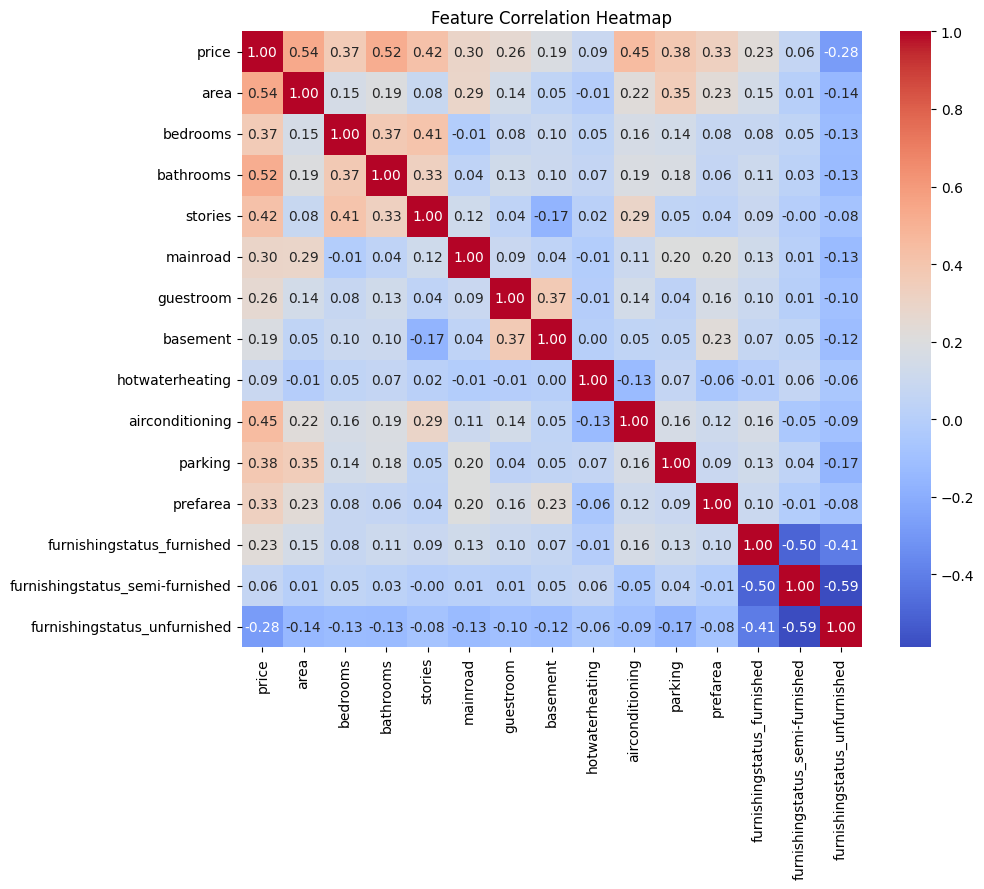

In [86]:
#task4
import matplotlib.pyplot as plt
import seaborn as sns

corr=df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()



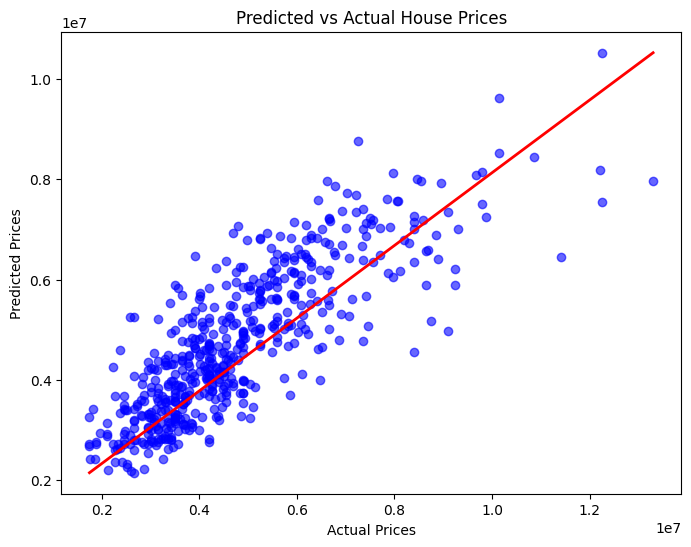

In [91]:
y_all_pred=trainer.predict(x)
plt.figure(figsize=(8,6))
plt.scatter(y, y_all_pred, alpha=0.6, color='blue') 
plt.plot([y.min(), y.max()], [y_all_pred.min(), y_all_pred.max()], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Predicted vs Actual House Prices')
plt.show()

In [92]:
#task5

new_house = pd.DataFrame({
    'area': [2400],
    'bedrooms': [4],
    'bathrooms': [3],
    'stories': [2],
    'mainroad': [1],         # yes → 1
    'guestroom': [0],        # no → 0
    'basement': [1],         # yes → 1
    'hotwaterheating': [0],  # no → 0
    'airconditioning': [1],  # yes → 1
    'parking': [2],
    'prefarea': [1],         # yes → 1
    # One-hot encoded furnishingstatus (assuming 'semi-furnished' only)
    'furnishingstatus_furnished': [0],
    'furnishingstatus_semi-furnished': [1],
    'furnishingstatus_unfurnished': [0]
})


num_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
new_house[num_cols] = scaler.transform(new_house[num_cols])  # use trained scaler


predicted_price = trainer.predict(new_house)
print("Predicted Price:", predicted_price[0])

Predicted Price: 7734050.277301256
